**Authors**: Caley, Gress

# Monopoly and Markov Chains


The goal of this project is to use Markov chains to model the game of Monopoly. We aim to answer some simple questions about the game:
- What are the locations visited the most often? 
- After how many turns is the game at an equilibrium?
- Is there a better strategy? Should one alway build hotels? Can we stick to houses?

To ease the analysis we will simplify some of the rules by simplifying the rules to get out of jail, and neglect the effect of the "Chance" and the "Community chest" cards. We will also consider players that always stick to the same strategy.

Most of the following analysis were motivated by two articles from Ian stewarts in the Scientific American, (reproductions from the articles are linked from the wayback machine [here](https://web.archive.org/web/20160310084056/https://www.math.yorku.ca/Who/Faculty/Steprans/Courses/2042/Monopoly/Monopoly.html) or available on the course page).



## Summary of the game

Those short explanations of the game are taken from [this website](http://www.durangobill.com/Monopoly.html). You can as well check the rules on the wikipedia page ([english](https://en.wikipedia.org/wiki/Monopoly_(game)), [german](https://de.wikipedia.org/wiki/Monopoly)). 

### Rules of the game

#### Dice Rolls: 

 - A player rolls **a pair of dice** and moves his board piece (token) clockwise around the board. The number of board spaces he moves is equal to the sum of the dice. 
 - If he stops on a "Chance" or "Community Chest" board space, he picks up a card from the indicated stack, and if instructed, moves his token to a new location. 
 - If he had doubles, he repeats this process. 
 - However, if he has three doubles in a row, he instead goes directly to Jail.

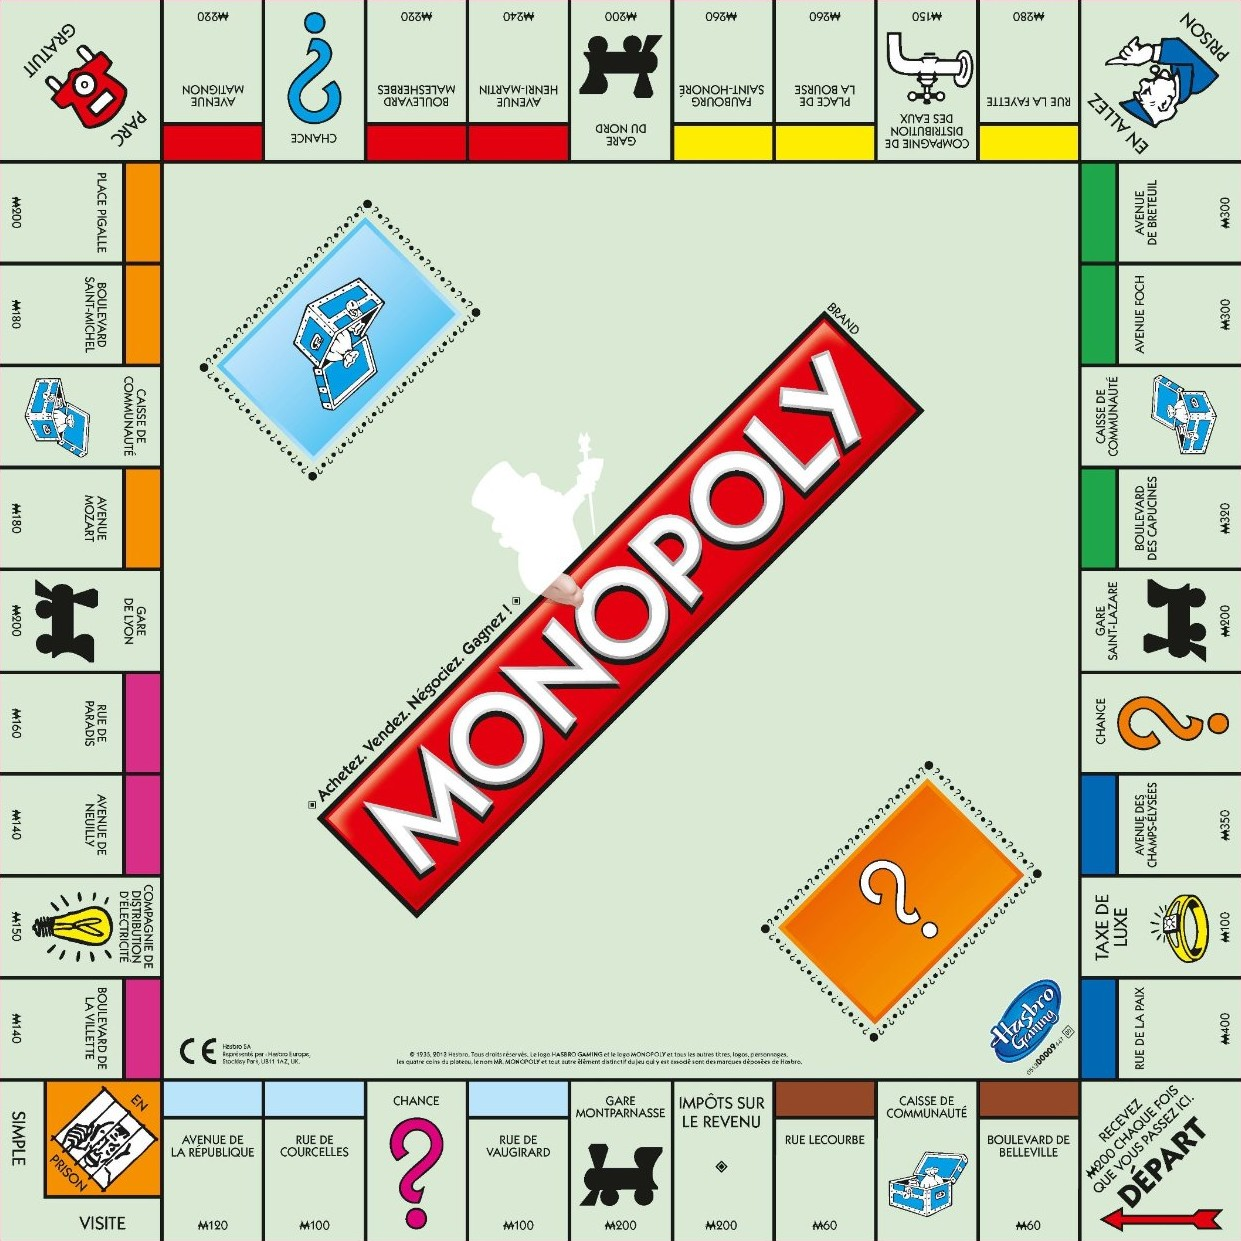



#### Going to Jail: 

If a player is instructed to go to Jail (at any point during his turn), his turn ends regardless of the doubles status. The player will stay at most 3 turns in Jail. He can go out of jail in one of the following manner:
- Paying is way out (50\$). In this case the token goes to "Just visiting" and the player can throw is dice as usual. 
- Using a Chance card. This is similar as paying 50\$.
- Rolling the dice. If there is a double, the player can go out and moves forwards of the number obtained with the dice. Note that in this case the player cannot roll the dice again (the double was "used" to get out of jail).


After the third turn, if the player does not get a double, he *must* pay 50\$ and moves of the number of spaces obtained with the dice.


# Monopoly and Markov Chains


The goal of this project is to use Markov chains to model the game of Monopoly. We aim to answer some simple questions about the game:
- What are the locations visited the most often? 
- After how many turns is the game at an equilibrium?
- Is there a better strategy? Should one alway build hotels? Can we stick to houses?

To ease the analysis we will simplify some of the rules by simplifying the rules to get out of jail, and neglect the effect of the "Chance" and the "Community chest" cards. We will also consider players that always stick to the same strategy.

Most of the following analysis were motivated by two articles from Ian stewarts in the Scientific American, (reproductions from the articles are linked from the wayback machine [here](https://web.archive.org/web/20160310084056/https://www.math.yorku.ca/Who/Faculty/Steprans/Courses/2042/Monopoly/Monopoly.html) or available on the course page).



## Summary of the game

Those short explanations of the game are taken from [this website](http://www.durangobill.com/Monopoly.html). You can as well check the rules on the wikipedia page ([english](https://en.wikipedia.org/wiki/Monopoly_(game)), [german](https://de.wikipedia.org/wiki/Monopoly)). 

### Rules of the game

#### Dice Rolls: 

 - A player rolls **a pair of dice** and moves his board piece (token) clockwise around the board. The number of board spaces he moves is equal to the sum of the dice. 
 - If he stops on a "Chance" or "Community Chest" board space, he picks up a card from the indicated stack, and if instructed, moves his token to a new location. 
 - If he had doubles, he repeats this process. 
 - However, if he has three doubles in a row, he instead goes directly to Jail.

![monopoly-classique-plateau.jpg](attachment:monopoly-classique-plateau.jpg)



#### Going to Jail: 

If a player is instructed to go to Jail (at any point during his turn), his turn ends regardless of the doubles status. The player will stay at most 3 turns in Jail. He can go out of jail in one of the following manner:
- Paying is way out (50\$). In this case the token goes to "Just visiting" and the player can throw is dice as usual. 
- Using a Chance card. This is similar as paying 50\$.
- Rolling the dice. If there is a double, the player can go out and moves forwards of the number obtained with the dice. Note that in this case the player cannot roll the dice again (the double was "used" to get out of jail).


After the third turn, if the player does not get a double, he *must* pay 50\$ and moves of the number of spaces obtained with the dice.


## 1. Setting up the Markov Chain

In this first part we will set up the parameters for a Markov chain that models the movements of the token of the board from turn to turn. 
We make the following simplification to the rules: 
- Double with the Dice does not allow a second roll.
- We do not consider the cards in the Chance and Community chest slots.
- When getting into Jail, the player always pays 50\$ at the first turn to get out of jail.


We start by constructing the markov chain.

In [332]:
import numpy as np

# Sorry the street names are in French!
# you can replace it with the colors as in the table file
squares = [
    "Départ",
    "Boulevard de Belleville",
    "Caisse de Communauté-1",
    "Rue Lecourbe",
    "Impôts sur le Revenu",
    "Gare Montparnasse",
    "Rue de Vaugirard",
    "Chance-1",
    "Rue de Courcelles",
    "Avenue de la République",
    "Visite de Prison",
    "Boulevard de la Villette",
    "Compagnie de Distribution d Électricité",
    "Avenue de Neuilly",
    "Rue de Paradis",
    "Gare de Lyon",
    "Avenue Mozart",
    "Caisse de Communauté-2",
    "Boulevard Saint-Michel",
    "Place Pigalle",
    "Parc Gratuit",
    "Avenue Matignon",
    "Chance-2",
    "Boulevard Malesherbes",
    "Avenue Henri-Martin",
    "Gare du Nord",
    "Faubourg Saint-Honoré",
    "Place de la Bourse",
    "Compagnie de Distribution des Eaux",
    "Rue La Fayette",
    "Allez en Prison",
    "Avenue de Breteuil",
    "Avenue Foch",
    "Caisse de communauté-3",
    "Boulevard des Capucines",
    "Gare Saint-Lazare",
    "Chance-3",
    "Avenue des Champs-Élysées",
    "Taxe de Luxe",
    "Rue de la Paix",
]

# squares += ["Prison"] # I will worry about this later
n_squares = len(squares)

# Some easy links
dict_squares = dict((x, i) for i, x in enumerate(squares))
iprison = dict_squares["Allez en Prison"]  ## This square is in fact never visited
ivisite = dict_squares["Visite de Prison"]

# Construct a 13 element array with all dice probabilities
two_dices = np.zeros(13, dtype=np.float32)

for d1_a in range(1, 7):
    for d2_a in range(1, 7):
        two_dices[d1_a + d2_a] += 1

two_dices /= 36

# The initial probability
pi = np.zeros((1, n_squares))
pi[0, 0] = 1

# Set up the Transition Matrix
A = np.zeros((n_squares, n_squares), dtype=np.float32)

### YOUR CODE HERE
for i in range(n_squares):
    for roll, prob in enumerate(two_dices):
        if prob > 0:
            dest = (i + roll) % n_squares
            if dest == iprison:
                dest = ivisite
            A[i, dest] += prob

A[iprison, :] = 0.0
A[iprison, ivisite] = 1.0

In [333]:
# check rows sum to 1:
np.allclose(A.sum(axis=1), 1)

True


## 2. After a few game turns.

Compute the probability of occupation on the board after a few turns of games. You will produce a set of histograms in the like of the one below


![monopoly_probas.png](attachment:monopoly_probas.png)

In [334]:
pi

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.]])

In [335]:
A[0]

array([0.        , 0.        , 0.02777778, 0.05555556, 0.08333334,
       0.11111111, 0.1388889 , 0.16666667, 0.1388889 , 0.11111111,
       0.08333334, 0.05555556, 0.02777778, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ],
      dtype=float32)

In [336]:
pi_3 = pi @ np.linalg.matrix_power(A, 3)
pi_13 = pi @ np.linalg.matrix_power(A, 13)

In [337]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

turns = [1, 2, 3, 6, 13]

fig = make_subplots(
    rows=len(turns),
    cols=1,
    subplot_titles=[f"Board distribution after {t} turns" for t in turns],
    shared_xaxes=True,
    vertical_spacing=0.03,
)

for i, turn in enumerate(turns, start=1):
    pi_n = pi @ np.linalg.matrix_power(A, turn)
    fig.add_trace(go.Bar(x=squares, y=pi_n.flatten(), showlegend=False), row=i, col=1)

fig.update_layout(
    height=250 * len(turns),
    width=1000,
    title="Monopoly board occupation probabilities",
)

fig.update_xaxes(tickangle=-90)
fig.update_yaxes(range=[0, 0.2])
fig.show()

## 3.a Computing the stationary distribution


Compute the stationary distribution $\mu$ of the Markov Chain, by using either one of the following properties:
 - $\lim_{n\rightarrow \infty} A^n = \mu$
 - $\mu \cdot A = \mu$. In other word $\mu$ is the eigenvector associated with the eigenvalue $1$.
 
Both can be obtained with the linear algebra functions of numpy. 

Verify that you get something similar to this image (this will not be exactly the same as it was obtained from a more detailled model):

![monopoly_stationary.png](attachment:monopoly_stationary.png)


In [338]:
pi_inf = np.linalg.matrix_power(A, 100)[0]

In [339]:
# check this is the stationary distribution:
pi_check = pi_inf @ A
assert np.allclose(pi_inf, pi_check)

In [340]:
import plotly.express as px

fig = px.bar(
    x=dict_squares.keys(),
    y=pi_inf,
    title="Stationary distribution of Monopoly Markov chain",
)

fig.update_layout(
    xaxis_tickangle=-90,
    height=500,
    width=1000,
)

fig.show()

**Question: Can you explain why some locations are more visited than others?**

Because of the "go to jail" square, jail is the most likely square for you to visit, there is a increase in the...

## 3b. Convergence to the stationary distribution

Use the successive powers of the matrix to determine the number of turns after which the chain converged to the stationary distribution (_e.g._ when the difference between the distribution of the rows of the matrix and the stationary distribution is below 1%)



In [341]:
def check(A, pi):
    for row in A:
        if not np.allclose(row, pi, 0.01):
            return False
    return True

In [342]:
for n in range(100):
    A_n = np.linalg.matrix_power(A, n)

    if check(A_n, pi_inf):
        print(n)
        break

45


## 3c. Evaluating investments   

We provide in attachment a table with all the incomes associated to the various properties of the board. Let's see how we can use that information to understand how to evaluate the various real estate investments on the board.

For each square $k$ of the monopoly, we thus know the cost $c_{k}$ of the property, the price $h_k$ of an house and the rent $r_{k,h}$ with $h$ house. The total cost of a property with $h$ house is $c_{k,h}= c_k + h\cdot h_k$ 

1. Verify that the expected income per opponent turn on square $k$ is $i_{k,h} = \mu_k \cdot r_{k,h}$ and compute this value for all square and all number of houses. For instance a property where an opponent as 5% chance of landing with a rent of 100\$ provides an expected income per turn of 5\$.

2. Now an interesting quantity is the expected number of opponents turns before we are able to return on our investment with buying the property. For instance if the property mentionned in q.1 costed 50\$, given that we expect to earn 5\$ per turn with no house, our average waiting time before returning on our investment will be after $\frac{50}{5}=10$ opponent turns. Verify that the general formula for this value is:
$$
e_{k,h} = \frac{c_{k,h}} {i_{k,h}}
$$

3. compute $e_{k,h}$ for all square and all number of houses and check the most rentable properties, as a function of the number of houses.

4. *Optional: Compute the expected number of turns to get a return of investment on a given color.*

5. **Question: A classical recommendation for Monopoly is to buy orange properties, can you back up this claim?**

In [343]:
import pandas as pd

squares_df = pd.read_csv("Data/Monopoly_squares_data.csv")
squares_df.head()

,Slot,Cost,RENT_empty_property,RENT_color_set,RENT_1house,RENT_2houses,RENT_3houses,RENT_4houses,RENT_hotel,house_cost
0,Go,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Brown 1,60.0,2.0,4.0,10.0,30.0,90.0,160.0,250.0,50.0
2,Community Chest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brown 2,60.0,4.0,8.0,20.0,60.0,180.0,320.0,450.0,50.0
4,Income Tax,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [344]:
## (1) verify: expected value of a bernoulli trial is its probability
# TODO: what do they mean by verify
rent_options = [
    "RENT_empty_property",
    "RENT_1house",
    "RENT_2houses",
    "RENT_3houses",
    "RENT_4houses",
]

for col in rent_options:
    # Compute i_k_h
    squares_df[f"i_kh_{col}"] = np.array(squares_df[col]) * pi_inf

# quick look... looks good
squares_df.filter(like="i_kh").head()

,i_kh_RENT_empty_property,i_kh_RENT_1house,i_kh_RENT_2houses,i_kh_RENT_3houses,i_kh_RENT_4houses
0,NaN,NaN,NaN,NaN,NaN
1,0.046236,0.231180,0.693539,2.080617,3.698875
2,NaN,NaN,NaN,NaN,NaN
3,0.094287,0.471436,1.414307,4.242922,7.542972
4,NaN,NaN,NaN,NaN,NaN


In [345]:
# (2) verify e_k_h = cost(k) / i_k_h
# TODO: what do they mean by verify

In [346]:
# (3) calculate e_k_h
for n_house, col in enumerate(rent_options):
    base_cost = squares_df["Cost"]
    house_cost = squares_df["house_cost"]
    # add total cost col hereß?

    # Compute e_k_h
    squares_df[f"e_kh_{col}"] = (base_cost + (house_cost * n_house)) / squares_df[
        f"i_kh_{col}"
    ]

squares_df.filter(like="e_kh").head()

,e_kh_RENT_empty_property,e_kh_RENT_1house,e_kh_RENT_2houses,e_kh_RENT_3houses,e_kh_RENT_4houses
0,NaN,NaN,NaN,NaN,NaN
1,1297.691862,475.820349,230.700776,100.931589,70.291643
2,NaN,NaN,NaN,NaN,NaN
3,636.353949,233.329781,113.129591,49.494196,34.469172
4,NaN,NaN,NaN,NaN,NaN


In [347]:
import matplotlib.pyplot as plt

In [348]:
squares_df.columns

Index(['Slot', 'Cost', 'RENT_empty_property', 'RENT_color_set', 'RENT_1house',
       'RENT_2houses', 'RENT_3houses', 'RENT_4houses', 'RENT_hotel',
       'house_cost', 'i_kh_RENT_empty_property', 'i_kh_RENT_1house',
       'i_kh_RENT_2houses', 'i_kh_RENT_3houses', 'i_kh_RENT_4houses',
       'e_kh_RENT_empty_property', 'e_kh_RENT_1house', 'e_kh_RENT_2houses',
       'e_kh_RENT_3houses', 'e_kh_RENT_4houses'],
      dtype='object')

e_kh_RENT_empty_property
['Rue de la Paix', 'Avenue de Breteuil', 'Rue La Fayette', 'Faubourg Saint-Honoré', 'Place de la Bourse', 'Avenue Foch']
e_kh_RENT_1house
['Rue La Fayette', 'Place Pigalle', 'Faubourg Saint-Honoré', 'Place de la Bourse', 'Boulevard des Capucines', 'Avenue des Champs-Élysées']
e_kh_RENT_2houses
['Rue La Fayette', 'Faubourg Saint-Honoré', 'Place de la Bourse', 'Boulevard des Capucines', 'Place Pigalle', 'Avenue de Breteuil']
e_kh_RENT_3houses
['Place Pigalle', 'Boulevard Saint-Michel', 'Rue La Fayette', 'Avenue Mozart', 'Faubourg Saint-Honoré', 'Place de la Bourse']
e_kh_RENT_4houses
['Place Pigalle', 'Boulevard Saint-Michel', 'Avenue Mozart', 'Avenue de la République', 'Rue de Paradis', 'Rue La Fayette']


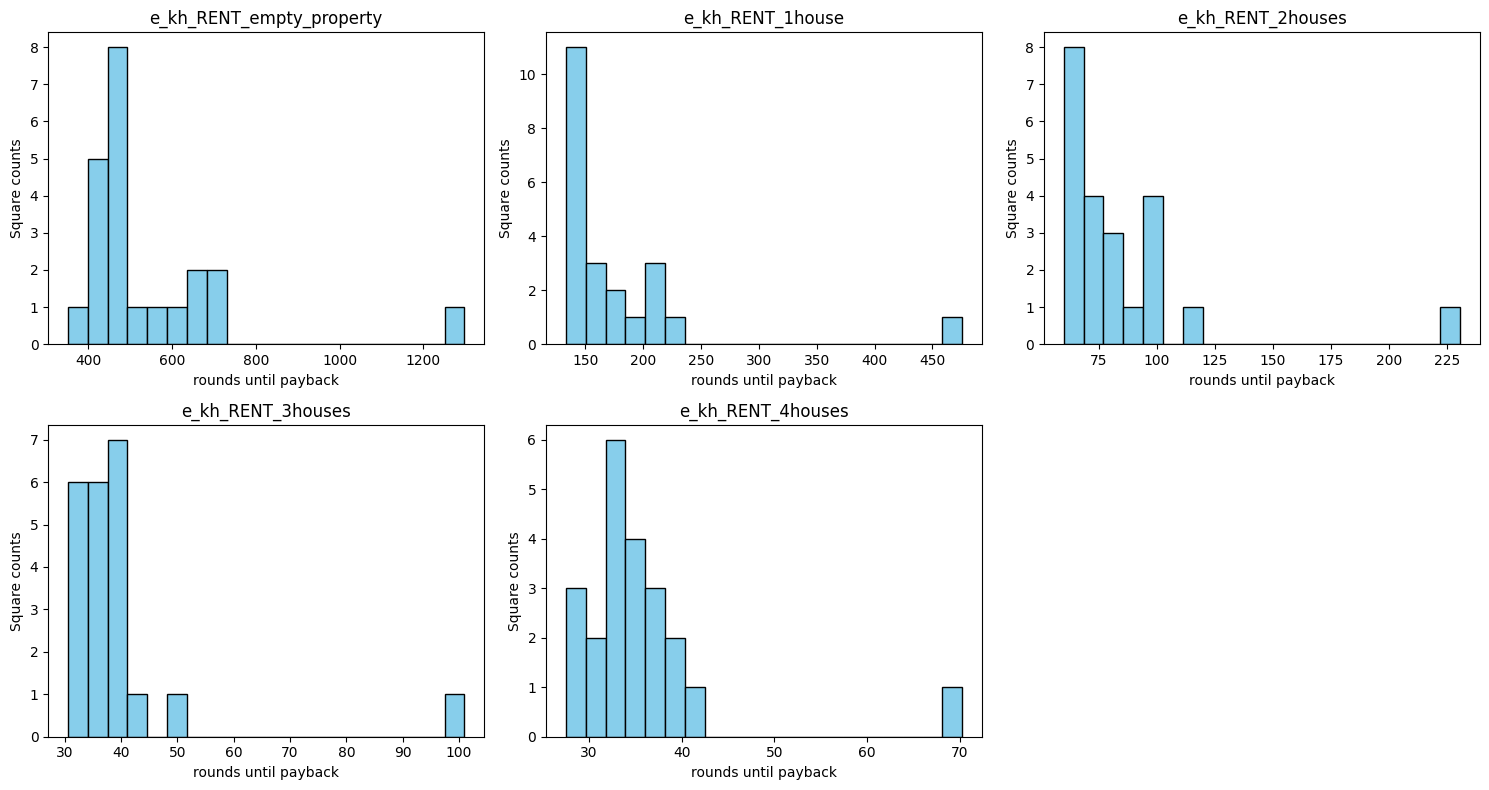

In [349]:
import matplotlib.pyplot as plt
import math

# Calculate grid dimensions based on the number of options
n_plots = len(rent_options)
n_cols = 3  # You can adjust this for a wider or narrower grid
n_rows = math.ceil(n_plots / n_cols)

# Create the figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()  # Flatten to iterate easily if it's a 2D array

for i, col in enumerate(rent_options):
    column_name = f"e_kh_{col}"

    sorted_idx = squares_df[column_name].sort_values().index
    print(column_name)
    print([squares[i] for i in sorted_idx[:6]])
    
    # Plotting on the specific subplot axis
    axes[i].hist(squares_df[column_name], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(column_name)
    axes[i].set_xlabel("rounds until payback")
    axes[i].set_ylabel("Square counts")

# Hide any unused subplots (if n_plots < n_rows * n_cols)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [350]:
# 4. *Optional: Compute the expected number of turns to get a return of investment on a given color.*

colour_opt = [
    "Brown",
    "Light Blue",
    "Pink",
    "Orange",
    "Red",
    "Yellow",
    "Green",
    "Dark Blue",
]

colours = []

for i, row in squares_df.iterrows():
    if (c := row[0].split(" ")[0]) in colour_opt:
        colours.append(c)
    else:
        colours.append(pd.NA)

squares_df["colour"] = colours

C:\Users\misog\AppData\Local\Temp\ipykernel_10152\3366234240.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if (c := row[0].split(" ")[0]) in colour_opt:


In [351]:
# 5. **Question: A classical recommendation for Monopoly is to buy orange properties, can you back up this claim?**

for i, col in enumerate(rent_options):
    column_name = f"e_kh_{col}"

    sorted_idx = squares_df[column_name].sort_values().index
    print(column_name)
    print(squares_df["colour"].iloc[sorted_idx[:6]])


e_kh_RENT_empty_property
39      <NA>
31     Green
29    Yellow
26    Yellow
27    Yellow
32     Green
Name: colour, dtype: object
e_kh_RENT_1house
29    Yellow
19    Orange
26    Yellow
27    Yellow
34     Green
37      <NA>
Name: colour, dtype: object
e_kh_RENT_2houses
29    Yellow
26    Yellow
27    Yellow
34     Green
19    Orange
31     Green
Name: colour, dtype: object
e_kh_RENT_3houses
19    Orange
18    Orange
29    Yellow
16    Orange
26    Yellow
27    Yellow
Name: colour, dtype: object
e_kh_RENT_4houses
19    Orange
18    Orange
16    Orange
9       <NA>
14      Pink
29    Yellow
Name: colour, dtype: object


**Answer:** Yes, Orange Slots generate the profit after the least turns in case of 3 and 4 houses, which is the fastest rental strategy.

## 4. Improving the model

By using the article provided on the moodle (also reproduced [at this adress](http://www.math.yorku.ca/Who/Faculty/Steprans/Courses/2042/Monopoly/Stewart4.html)), design a more realistic transition matrix that would take into account double on the dice as well as the traditional getting out of jail.

You will integrate the following ingredients:
  - Double allow the player to do a second roll.
  - After three double the player goes to jail.
  - To simplify, we also hypothesize that the player cannot buy properties on the intermediate squares in a serie of doubles. 
  - Player always try to get out of jail by throwing the dice up to three times
  - (optional) Account for the cards in Chance and community chests that redirect the token to other cases (more details are given in the article and you can look online what are the statistics for the cards)

To take this information into account in the Markov chain you can increase the state space by consider for each square the number of doubles you did when you landed on it. So now each square will correspond to 3 states in the Markov chain, the ID of the square, together with an additional field that stores the information about the number of doubles. 

For instance imagine you start from (0, "Départ"):
  - if you throw two 3, that's a double and you will land on square 6 ("Rue de Vaugirard") while keeping the information that you did a double so you will be in state (1, "Rue de Vaugirard"). 
  - if you throw a 2 and a 4, that's not a double and you will land on state (0, "Rue de Vaugirard").

In [352]:
from collections import defaultdict

In [353]:
# squares_with_prison = squares + ["Prison_1", "Prison_2", "Prison_3"]
# n_squares_with_prison = len(squares_with_prison)

# # Some more easy links
# dict_squares_with_prison = dict((x, i) for i, x in enumerate(squares_with_prison))
# iprison = dict_squares_with_prison["Allez en Prison"]
# ivisite = dict_squares_with_prison["Visite de Prison"]

# iprison_1 = dict_squares_with_prison["Prison_1"]
# iprison_2 = dict_squares_with_prison["Prison_2"]
# iprison_3 = dict_squares_with_prison["Prison_3"]

In [354]:
## Design the improved transition matrix here

def calculate_move(current_sum, current_p, depth):
    global jail_prob, d3_probs
    
    for d1 in range(1, 7):
        for d2 in range(1, 7):
            p_roll = (1/36) * current_p
            roll_sum = d1 + d2
            
            if d1 == d2:
                if depth == 2: # This is the 3rd double in a row
                    jail_prob += p_roll
                else:
                    calculate_move(current_sum + roll_sum, p_roll, depth + 1)
            else:
                d3_probs[current_sum + roll_sum] += p_roll

# Initialize
jail_prob = 0
d3_probs = np.zeros(36)
calculate_move(0, 1.0, 0)
d3_probs

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.55555556e-02,
       5.55555556e-02, 1.12654321e-01, 1.12654321e-01, 1.71339163e-01,
       1.15783608e-01, 1.20541838e-01, 6.34430727e-02, 6.83299040e-02,
       9.64506173e-03, 1.46604938e-02, 9.90226337e-03, 1.50462963e-02,
       1.01594650e-02, 1.38888889e-02, 8.87345679e-03, 1.11025377e-02,
       5.95850480e-03, 6.60150892e-03, 2.87208505e-03, 3.38648834e-03,
       1.15740741e-03, 1.54320988e-03, 9.00205761e-04, 1.15740741e-03,
       6.43004115e-04, 7.71604938e-04, 3.85802469e-04, 4.28669410e-04,
       1.71467764e-04, 1.71467764e-04, 4.28669410e-05, 4.28669410e-05])

In [355]:
jail_prob

0.004629629629629651

In [356]:
# Build transition matrix
A_dub = np.zeros((n_squares, n_squares), dtype=np.float32)


# first JUST CONSIDER transitioning from non-jail squares
for i in range(n_squares):

    # normal roll outcomes
    for roll, prob in enumerate(d3_probs):

        if prob > 0:

            dest = (i + roll) % n_squares

            if i == ivisite:
                continue
            if i == iprison:
                A_dub[i,dest] ==0
            
            if dest == iprison:
                #continue
                dest = ivisite
            A_dub[i, dest] += prob

    # triple-double
    A_dub[i, ivisite] += jail_prob

# prisonbreak 1
for d in [2,4,6,8,10,12]:
    A_dub[ivisite, ivisite + d] += 1/36 

# prisonbreak 2
for d in [2,4,6,8,10,12]:
    A_dub[ivisite, ivisite + d] += 30/36 * 1/36 

# prisonbreak 3
d2_roll = np.zeros(13)
for d1_a in range(1, 7):
    for d2_a in range(1, 7):
        d2_roll[d1_a + d2_a] += 1

for i, d in enumerate(d2_roll):
    if d>0:
        A_dub[ivisite, ivisite + i] += (30/36 * 30/36) * d/36


In [357]:
A_dub.sum(axis=1)

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.0046296 , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.99999994,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ],
      dtype=float32)

In [358]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

pi = np.zeros(n_squares)
pi[0]=1
turns = [1, 2, 3, 6, 13]

fig = make_subplots(
    rows=len(turns),
    cols=1,
    subplot_titles=[f"Board distribution after {t} turns" for t in turns],
    shared_xaxes=True,
    vertical_spacing=0.03,
)

for i, turn in enumerate(turns, start=1):

    pi_n = pi @ np.linalg.matrix_power(A_dub, turn)

    fig.add_trace(
        go.Bar(
            x=squares,
            y=pi_n.flatten(),
            showlegend=False,
        ),
        row=i,
        col=1,
    )

fig.update_layout(
    height=250 * len(turns),
    width=1000,
    title="Monopoly board occupation probabilities",
)

fig.update_xaxes(tickangle=-90)
fig.update_yaxes(range=[0, 0.2])

fig.show()

Recompute the values of question 2 and 3a with this new matrix and comment on possible difference.

In [359]:
pi_inf = np.linalg.matrix_power(A_dub, 10000)[0]
# when 10 000, we encounter underflow

In [360]:
pi_inf

array([0.28021365, 0.27405742, 0.285427  , 0.28024703, 0.27624145,
       0.27441305, 0.27379405, 0.27415705, 0.27481222, 0.2756369 ,
       0.64658713, 0.27562857, 0.3205683 , 0.28423825, 0.32926714,
       0.29526633, 0.34111553, 0.31016684, 0.3476305 , 0.31038097,
       0.34765276, 0.31156012, 0.34770784, 0.31177753, 0.30986127,
       0.31803653, 0.31466797, 0.31995848, 0.31591186, 0.31898695,
       0.        , 0.31651083, 0.31435046, 0.29812643, 0.29718292,
       0.27976263, 0.27890685, 0.25929463, 0.27349734, 0.26868355],
      dtype=float32)

In [361]:
# check this is the stationary distribution:
pi_check = pi_inf @ A_dub
pi_check
#assert np.allclose(pi_inf, pi_check) 
# assert fails, although it looks close to me

array([0.2802834 , 0.27412555, 0.285498  , 0.2803167 , 0.27631018,
       0.27448136, 0.27386212, 0.27422523, 0.27488062, 0.27570546,
       0.6467481 , 0.27569708, 0.32064798, 0.28430894, 0.32934907,
       0.2953398 , 0.34120038, 0.31024393, 0.3477169 , 0.31045818,
       0.3477393 , 0.31163752, 0.34779438, 0.31185502, 0.30993834,
       0.31811568, 0.31474614, 0.32003814, 0.31599045, 0.3190663 ,
       0.        , 0.3165896 , 0.3144287 , 0.29820064, 0.29725692,
       0.27983227, 0.2789763 , 0.25935918, 0.27356544, 0.2687504 ],
      dtype=float32)

In [362]:
import plotly.express as px

fig = px.bar(
    x=dict_squares.keys(),
    y=pi_inf,
    title="Stationary distribution of Monopoly Markov chain",
)

fig.update_layout(
    xaxis_tickangle=-90,
    height=500,
    width=1000,
)

fig.show()